# Congressional Trade Data collection and processing
This notebook implements initial data and processes it


## 1. Load data
We load both the trade features dataset and calculated returns dataset.


In [1]:
# Load Raw Data
import pandas as pd
trades = pd.read_csv('../data/capitoltrades_data.csv')
print(f"Loaded {len(trades)} trades")
trades.head()

# Data Quality Checks
print("Missing values:")
print(trades.isnull().sum())

print("\nUnique values:")
print(f"Politicians: {trades['politician_name'].nunique()}")
print(f"Tickers: {trades['ticker'].nunique()}")
print(f"Parties: {trades['party'].value_counts()}")


Loaded 35136 trades
Missing values:
politician_name        0
party                 44
chamber                0
state                  0
issuer_name            0
ticker              4978
published_date         0
traded_date            0
filed_after_days       0
owner                  0
transaction_type       0
size                   0
price               6602
scraped_at             0
dtype: int64

Unique values:
Politicians: 196
Tickers: 1925
Parties: party
Democrat      21011
Republican    14081
Name: count, dtype: int64


## 2. Visualize data


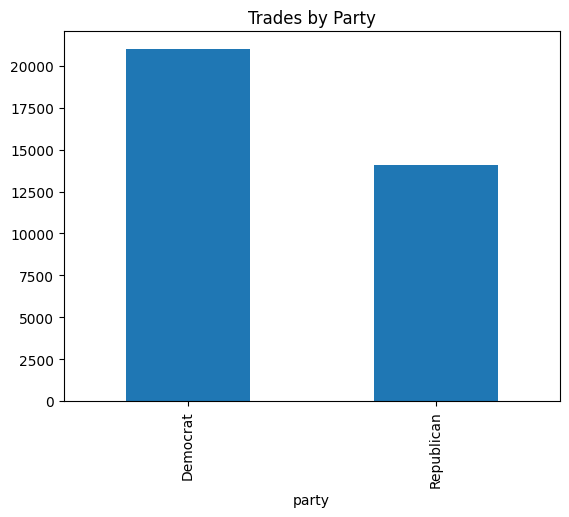

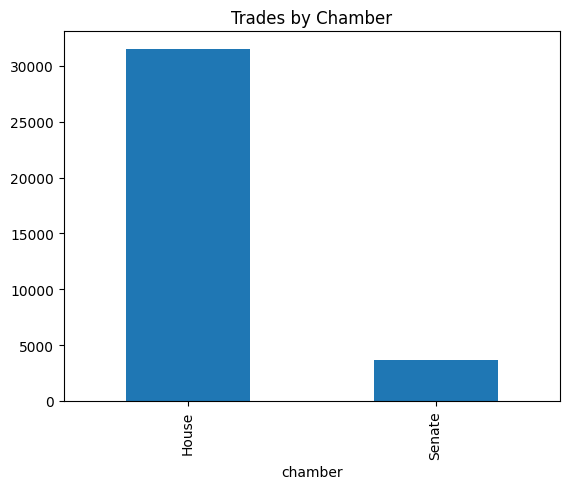

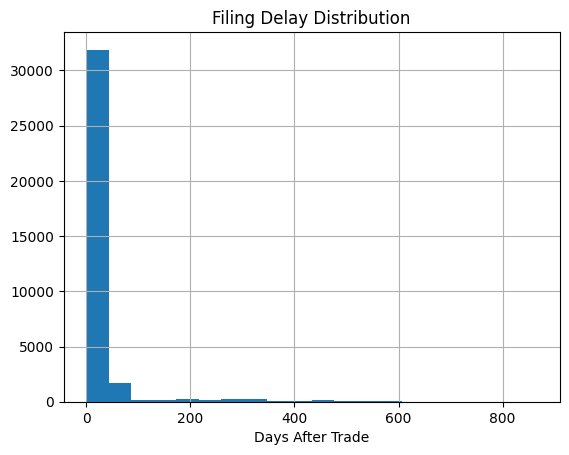

Top 10 Most Active Traders:
politician_name
Ro Khanna             12323
Michael McCaul         4681
Lisa McClain           1443
Josh Gottheimer        1391
Gil Cisneros           1201
Richard Blumenthal      727
Rob Bresnahan           652
Jefferson Shreve        630
Tommy Tuberville        589
Daniel S. Goldman       580
Name: count, dtype: int64


In [2]:
# Basic Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Trades by party
trades['party'].value_counts().plot(kind='bar')
plt.title('Trades by Party')
plt.show()

# Trades by chamber
trades['chamber'].value_counts().plot(kind='bar')
plt.title('Trades by Chamber')
plt.show()

# Filing delay distribution
trades['filed_after_days'].hist(bins=20)
plt.title('Filing Delay Distribution')
plt.xlabel('Days After Trade')
plt.show()

# Top Traders
top_traders = trades['politician_name'].value_counts().head(10)
print("Top 10 Most Active Traders:")
print(top_traders)


## 3. Process data

In [3]:
# Load All Data Sources
members = pd.read_csv('../data/legislators-current.csv')
committees = pd.read_csv('../data/committee-membership-current.csv')

# Preview Data
print("Trades shape:", trades.shape)
print("Members shape:", members.shape)
print("Committees shape:", committees.shape)

# Committee Power Calculation
committee_weights = {
    'SSFI': 5, 'SSAP': 5, 'SLIN': 5,
    'HSWM': 5, 'HSAP': 5, 'HSIF': 4,
    # ... etc
}

# Show power score distribution
processed = pd.read_csv('../data/trades_with_features.csv')
processed['committee_power_score'].describe()


Trades shape: (35136, 14)
Members shape: (538, 36)
Committees shape: (3908, 10)


count    26970.000000
mean         7.369410
std          3.468202
min          0.000000
25%          6.000000
50%          7.000000
75%          7.000000
max         25.000000
Name: committee_power_score, dtype: float64

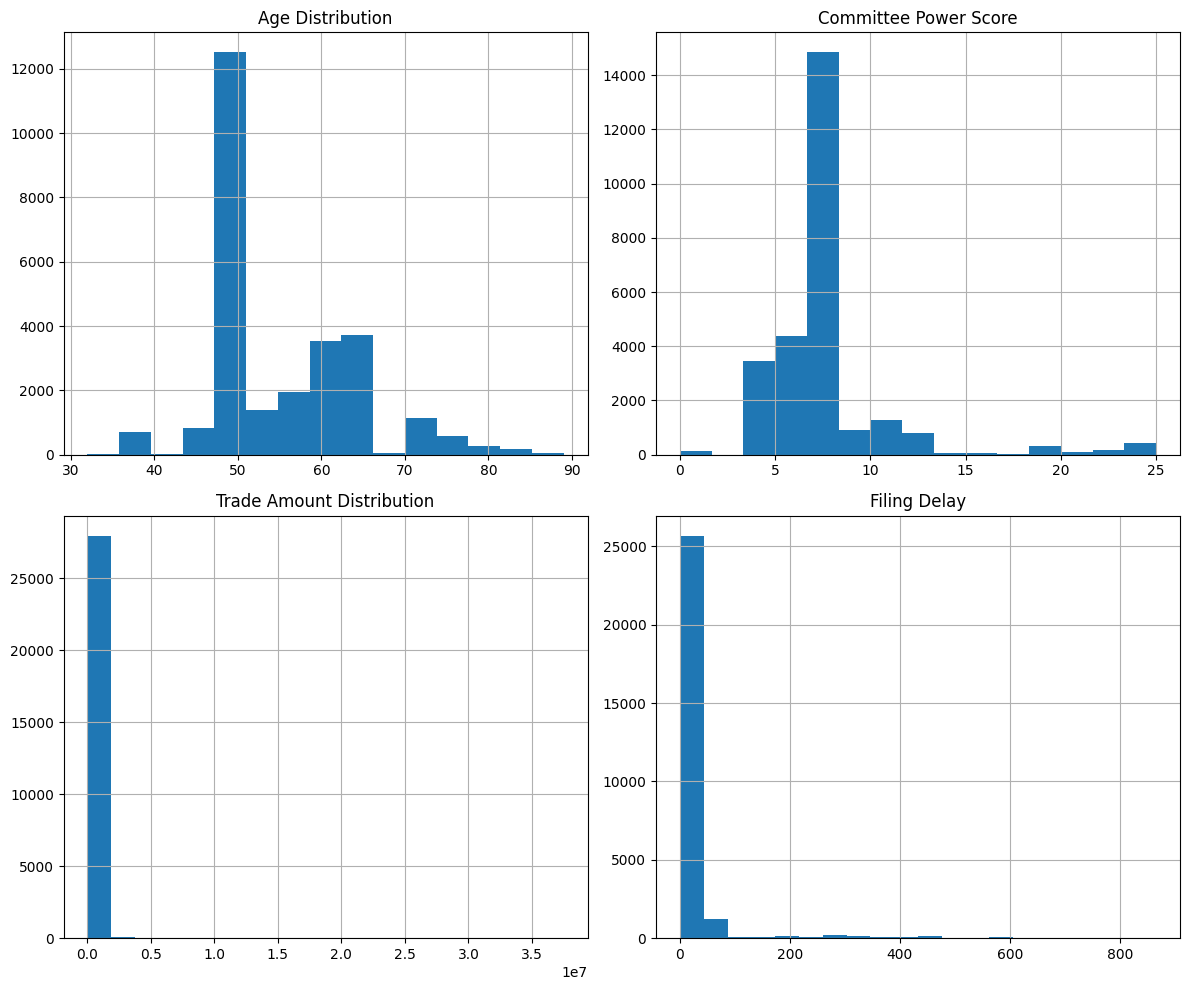

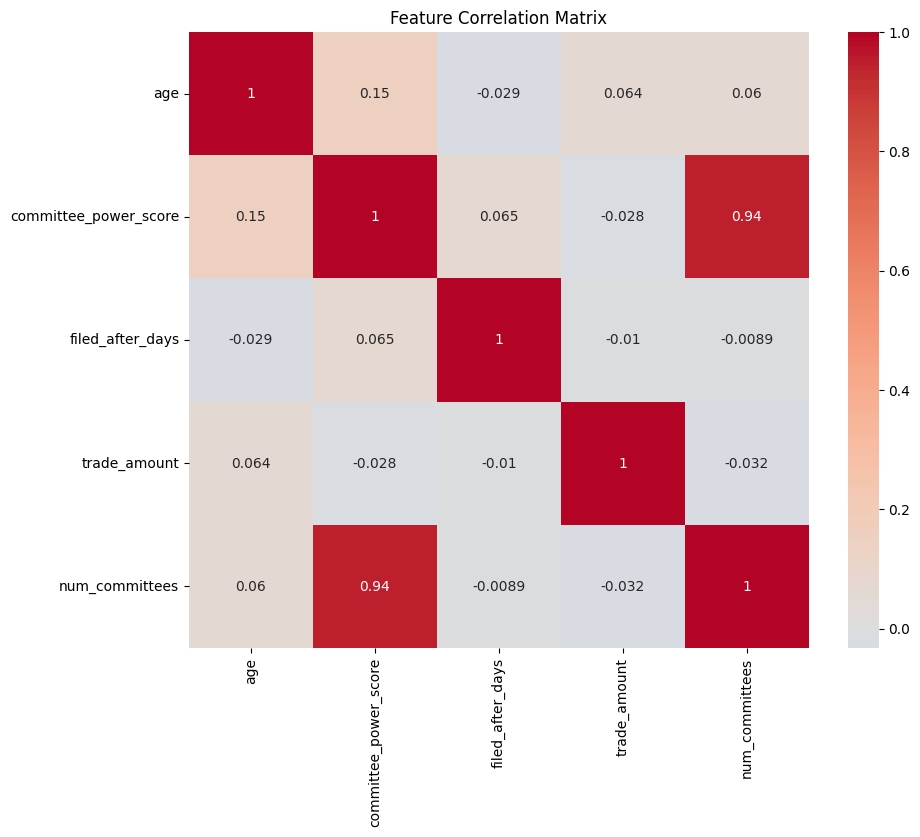

In [4]:

# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age distribution
processed['age'].hist(bins=15, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

# Committee power
processed['committee_power_score'].hist(bins=15, ax=axes[0,1])
axes[0,1].set_title('Committee Power Score')

# Trade amount
processed['trade_amount'].hist(bins=20, ax=axes[1,0])
axes[1,0].set_title('Trade Amount Distribution')

# Filing delay
processed['filed_after_days'].hist(bins=20, ax=axes[1,1])
axes[1,1].set_title('Filing Delay')

plt.tight_layout()
plt.show()

# Correlation Analysis
corr_features = ['age', 'committee_power_score', 'filed_after_days',
                 'trade_amount', 'num_committees']
corr_matrix = processed[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()